<a href="https://colab.research.google.com/github/amer-baniodeh/project-1-deep-learning-image-classification-with-cnn/blob/main/model_9_mnv2_daug_up.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model 9 - Transfer Learning with MobileNetV2
with resizing images (96,96), Data Augmentation and Upscaling.

<br>

 - accuracy: 0.9452 - loss: 0.1558 - val_accuracy: 0.9102 - val_loss: 0.2790

 - 19mins - 25 + 10 epochs

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical



from google.colab import drive
drive.mount('/content/drive')



'''
x_train_raw = np.load('/content/drive/MyDrive/IronHack/datasets/cifar10_data/x_train.npy')
y_train_raw = np.load('/content/drive/MyDrive/IronHack/datasets/cifar10_data/y_train.npy')
x_test_raw = np.load('/content/drive/MyDrive/IronHack/datasets/cifar10_data/x_test.npy')
y_test_raw = np.load('/content/drive/MyDrive/IronHack/datasets/cifar10_data/y_test.npy')

'''
# Load the train data
x_train = np.load('/content/drive/MyDrive/x_train.npy')
y_train = np.load('/content/drive/MyDrive/y_train.npy')

# Load the test data
x_test = np.load('/content/drive/MyDrive/x_test.npy')
y_test = np.load('/content/drive/MyDrive/y_test.npy')


# Verify the shapes to make sure everything loaded correctly
print(f"x_train shape: {x_train.shape} | y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape} | y_test shape: {y_test.shape}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
x_train shape: (50000, 32, 32, 3) | y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3) | y_test shape: (10000, 1)


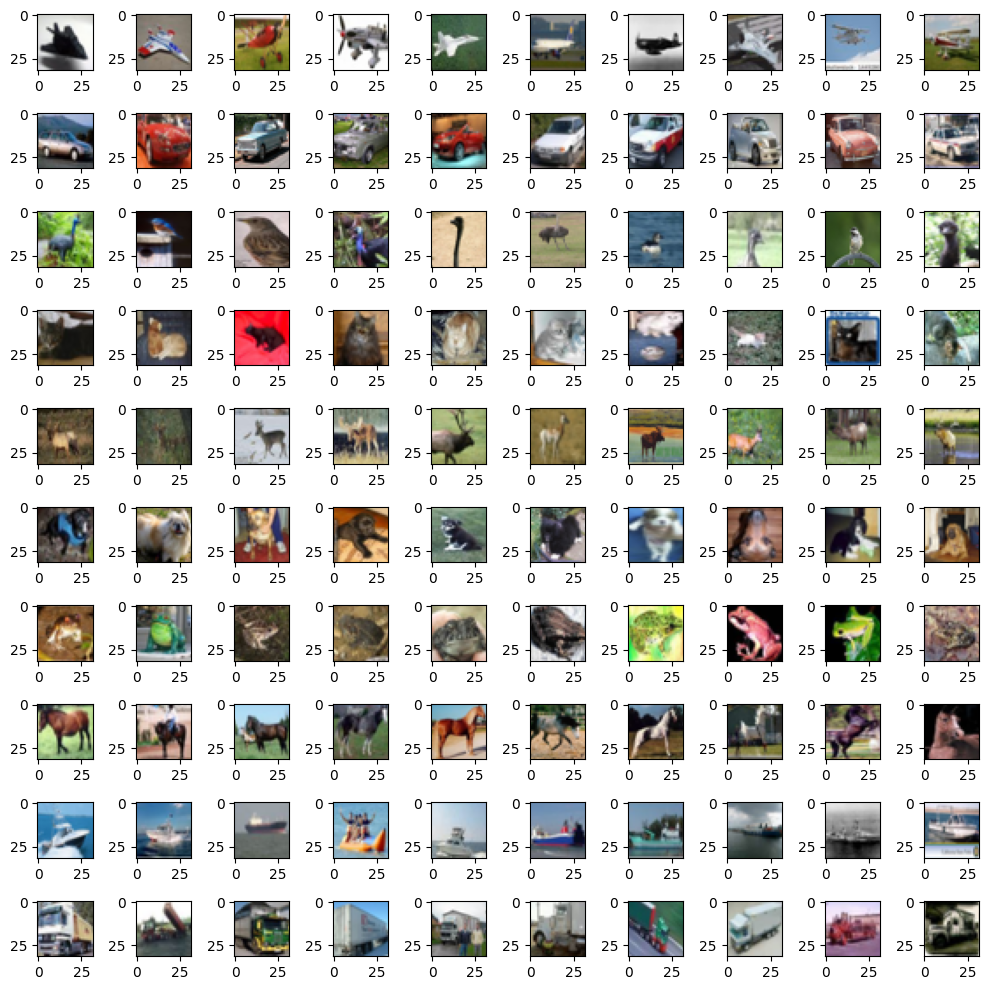

In [3]:
plt.figure(figsize=(10, 10))

for class_id in range(10):
    class_indices = np.where(y_train == class_id)[0]

    # Grab 10 samples for this class
    for sample_idx in range(10):
        # Calculate the 1-indexed grid position (1 to 100)
        position = (class_id * 10) + sample_idx + 1
        img_index = class_indices[sample_idx]

        plt.subplot(10, 10, position)
        plt.imshow(x_train[img_index])
        plt.axis('on')

plt.tight_layout()
plt.show()

In [4]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Use .item() instead of int()
sample_index = y_train[7].item()

print(f"Integer label: {sample_index}")
print(f"Human-readable label: {class_names[sample_index]}")

Integer label: 7
Human-readable label: horse


In [5]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

# SPLIT FIRST (e.g., 80% train, 20% validation)
# 'stratify=y_train_full' ensures an equal mix of CIFAR-10 classes in both sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# ONE-HOT ENCODE EVERYTHING
num_classes = 10
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_one_hot = tf.keras.utils.to_categorical(y_val, num_classes)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes)

# Check new shapes
print("Train shape:", y_train_one_hot.shape)  # Output: (40000, 10)
print("Val shape:", y_val_one_hot.shape)      # Output: (10000, 10)
print("Test shape:", y_test_one_hot.shape)    # Output: (10000, 10)

Train shape: (40000, 10)
Val shape: (10000, 10)
Test shape: (10000, 10)


In [6]:
#Normalise
#def normalize_images(df):
 #   df = df.astype('float32') / 255
  #  return df

#x_train = normalize_images(x_train)
#x_val = normalize_images(x_val)
#x_test = normalize_images(x_test)


# ---------------------------------------------------
#  - Preprocess CIFAR-10
# ---------------------------------------------------
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import to_categorical

#y_train = y_train_one_hot
#y_val = y_val_one_hot
#y_test = y_test_one_hot
#y_train = to_categorical(y_train, 10)
#y_test = to_categorical(y_test, 10)

# MobileNetV2 preprocessing expects pixel values scaled to [-1, 1]
#x_train = preprocess_input(x_train.astype('float32'))
#x_test = preprocess_input(x_test.astype('float32'))

x_train = preprocess_input(x_train.astype('float32'))
x_val = preprocess_input(x_val.astype('float32'))
x_test = preprocess_input(x_test.astype('float32'))

print("x_train range:", x_train.min(), "to", x_train.max()) # Should be roughly -1.0 to

print(x_train.shape)
print(x_val.shape)
print(x_test.shape)


x_train range: -1.0 to 1.0
(40000, 32, 32, 3)
(10000, 32, 32, 3)
(10000, 32, 32, 3)


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Resizing
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical


# 1. Define the Data Augmentation Sequential Block
# (These layers automatically turn off during model.evaluate() and model.predict())
data_augmentation = Sequential([
    RandomFlip("horizontal"),          # Randomly flip images left-to-right
    RandomRotation(0.05),               # Randomly rotate by up to 10% (-36 to +36 degrees)
    RandomZoom(0.05),                   # Randomly zoom in/out by 10%
], name="data_augmentation")

# 2. Re-initialize the MobileNetV2 base with a larger input shape
# (96x96 or 128x128 gives MobileNet enough spatial features to achieve high accuracy)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

# Unfreeze the base model entirely
base_model.trainable = True

# Freeze all layers EXCEPT the last 60 layers
for layer in base_model.layers[:-60]:
    layer.trainable = False

# 3. Build the Functional Model Pipeline
inputs = Input(shape=(32, 32, 3))

# Step A: Apply Augmentation (only activates during training)
x = data_augmentation(inputs)

# Step B: Upscale the 32x32 images up to 96x96
x = Resizing(96, 96, interpolation="bilinear")(x)

# Step C: Pass through the MobileNet base
x = base_model(x, training=False)

# Step D: Classification Head
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

# Combine into final model
model_mnv2 = Model(inputs, outputs)

# --- BEGIN ADDED CODE ---
# Dummy forward pass to build the model's graph and instantiate all weights
# This often resolves 'Creating variables on a non-first call to a tf.function' errors.
_ = model_mnv2(tf.zeros((1, 32, 32, 3)))
# --- END ADDED CODE ---

model_mnv2.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mnv2.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 2,120,970 (8.09 MB)

 Non-trainable params: 302,272 (1.15 MB)

In [8]:
# ---------------------------------------------------
# 2. Train the classification head (base frozen)
# ---------------------------------------------------
history = model_mnv2.fit(
    x_train, y_train_one_hot,
    validation_data=(x_val, y_val_one_hot),
    epochs=25,
    batch_size=64
)

# ---------------------------------------------------
# 3. Fine-tune: unfreeze the top layers of the base model
# ---------------------------------------------------
base_model.trainable = True

# Freeze all but the last ~30 layers (MobileNetV2 has ~150+ layers)
for layer in base_model.layers[:-30]:
    layer.trainable = False

model_mnv2.compile(
    optimizer=Adam(learning_rate=1e-5),  # low LR to avoid destroying pretrained features
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model_mnv2.fit(
    x_train, y_train_one_hot,
    validation_data=(x_val, y_val_one_hot),
    epochs=10,
    batch_size=64
)

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 57ms/step - accuracy: 0.4518 - loss: 1.6461 - val_accuracy: 0.7524 - val_loss: 0.7666
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.7139 - loss: 0.8561 - val_accuracy: 0.8351 - val_loss: 0.4956
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.7700 - loss: 0.6863 - val_accuracy: 0.8579 - val_loss: 0.4183
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 55ms/step - accuracy: 0.7991 - loss: 0.5988 - val_accuracy: 0.8663 - val_loss: 0.3877
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.8161 - loss: 0.5506 - val_accuracy: 0.8750 - val_loss: 0.3627
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.8293 - loss: 0.5076 - val_accuracy: 0.8813 - val_loss: 0.3467
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.8407 - loss: 0.4746 - val_accuracy: 0.8863 - val_loss: 0.3379
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.8490 - loss: 0.4460 - 

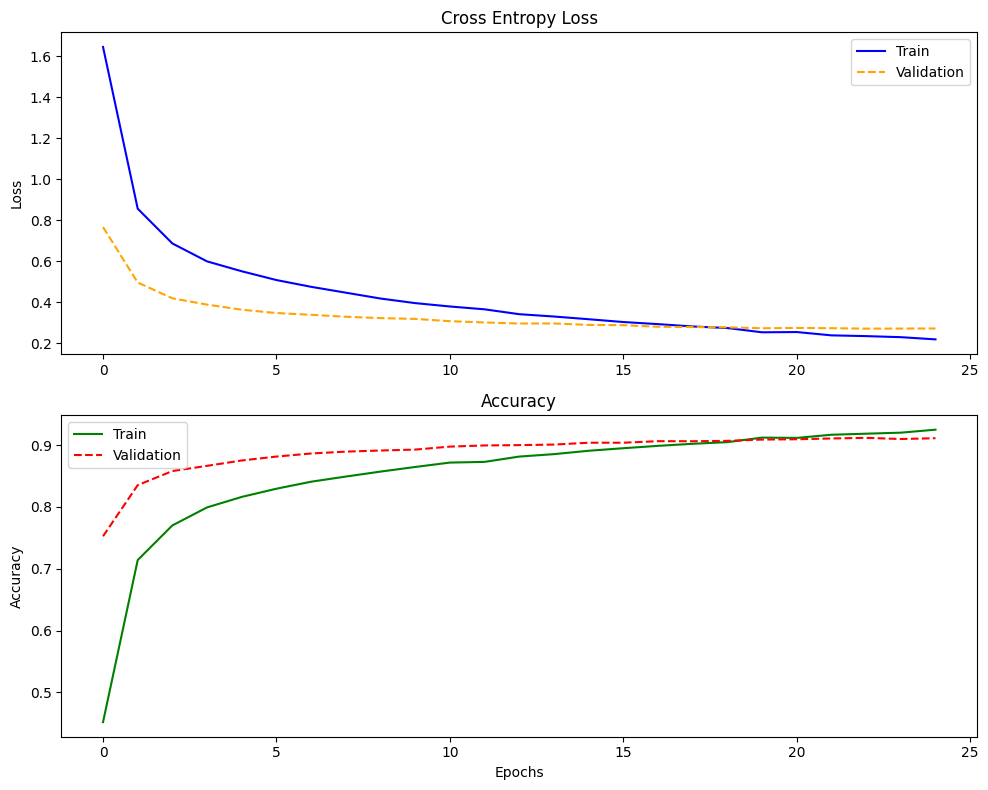

In [9]:
import matplotlib.pyplot as plt

# Set up a clean figure size
plt.figure(figsize=(10, 8))

# 1. Plot the Cross Entropy Loss Curve
plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='Train')
plt.plot(history.history['val_loss'], color='orange', label='Validation', linestyle='--')
plt.ylabel('Loss')
plt.legend()

# 2. Plot the Accuracy Curve
plt.subplot(212)
plt.title('Accuracy')
plt.plot(history.history['accuracy'], color='green', label='Train')
plt.plot(history.history['val_accuracy'], color='red', label='Validation', linestyle='--')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()

# Automatically clean up spacing between subplots
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step


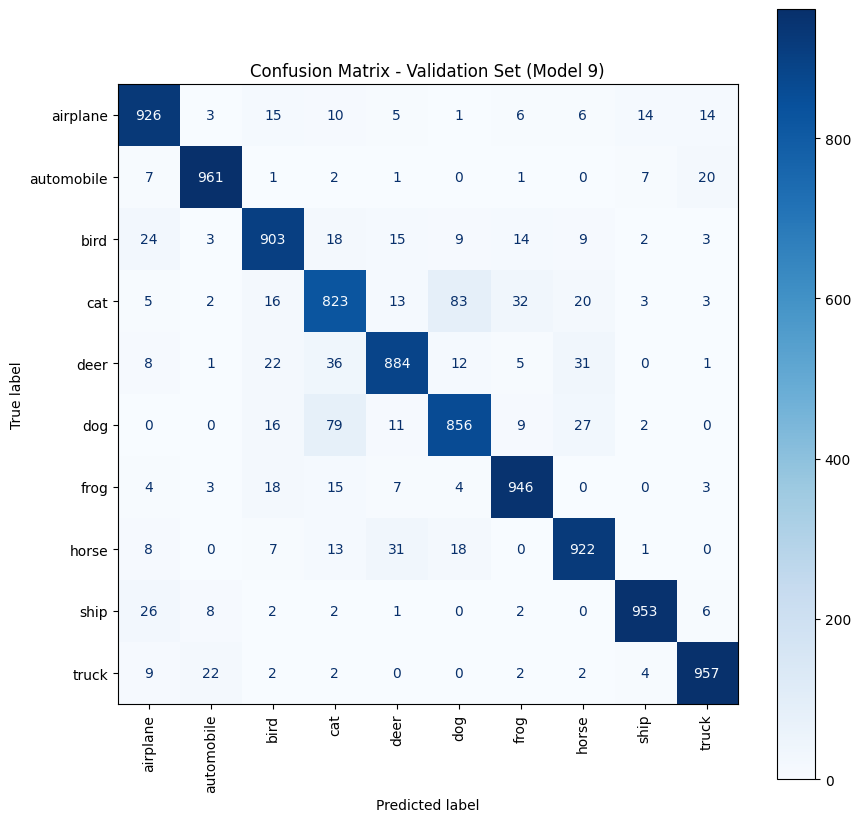

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Get model predictions on the VALIDATION set
y_pred_probs = model_mnv2.predict(x_val)

# 2. Convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Ensure your true validation labels are flat (1D array)
y_true = y_val.flatten()

# 4. Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 5. Define the CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 6. Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')

plt.title('Confusion Matrix - Validation Set (Model 9)')
plt.show()

In [11]:
# Saving Model in Google Drive

#save at Antonio's drive
model_mnv2.save("/content/drive/MyDrive/IronHack/Models/model_9.keras")

#save at Amer's drive
#model_mnv2.save("/content/drive/MyDrive/Models/model_9.keras")



FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/IronHack/Models/model_9.keras'

In [ ]:

from tensorflow.keras.models import load_model

# Checking the saved model file is Valid
m = load_model("/content/drive/MyDrive/IronHack/Models/model_9.keras")
print("Loaded successfully")

#################################
# OPTIONAL PICKLE INSTRUCTIONS
#################################
# import pickle
#
#model_path = "/content/drive/MyDrive/Models/model_3.keras"
#
#with open(model_path, "wb") as f:
#    pickle.dump(model, f)
#
#print("Model saved to:", model_path)
#
#
#with open(model_path, "rb") as f:
#    loaded_model = pickle.load(f)
#
#print("Model loaded successfully!")
#
